In [2]:
!pip install nibabel scikit-image batchgenerators
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
from skimage.transform import resize
import os
from glob import glob
import torch.nn.functional as F


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached nibabel-5.4.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached batchgenerators-0.25.1-py3-none-any.whl
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached unittest2-1.1.0-py2.py3-none-any.whl.metadata (15 kB)
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached traceback2-1.4.0-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached linecache2-1.0.0-py2.py3-none-any.whl.metadata (1000 bytes)
Using cached nibabel-5.4.2-py3-none-any.whl (3.3 MB)
Using cached future-1.0.0-py3-none-any.whl (491 kB)
Using cached unittest2-1.1.0-py2.py3-none-any.whl (96 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
Using cached traceback2-1.4.0-py2.py3-none-any.whl (16 kB)
Using cached linecache2-1.0.0-py2.py3-none-any.whl (12 kB)

   ----------- ---------------------------- 2/7 [traceback2]
   ----------------- ---------------------- 3/7 [nibabel]
   ----------------- ---------------------- 3/7 [nibabel]
   ---------------

In [3]:
def test_your_data():
    DATA_PATH = "D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

    print("正在测试你的数据...")

    case_pattern = os.path.join(DATA_PATH, "BraTS*")
    case_dirs = glob(case_pattern)
    case_dirs = [d for d in case_dirs if os.path.isdir(d)]

    print(f"找到 {len(case_dirs)} 个病例目录")

    # 检查第一个病例的文件
    first_case = case_dirs[0]
    case_name = os.path.basename(first_case)
    print(f"\n检查病例: {case_name}")

    expected_files = {
        't1': os.path.join(first_case, f"{case_name}_t1.nii"),
        't1ce': os.path.join(first_case, f"{case_name}_t1ce.nii"),
        't2': os.path.join(first_case, f"{case_name}_t2.nii"),
        'flair': os.path.join(first_case, f"{case_name}_flair.nii"),
        'seg': os.path.join(first_case, f"{case_name}_seg.nii")
    }
    print("查找文件:")
    for mod, file_path in expected_files.items():
        exists = os.path.exists(file_path)
        status = "✓" if exists else "✗"
        print(f"  {status} {os.path.basename(file_path)}: {'找到' if exists else '未找到'}")

    # 检查所有必要文件是否存在
    required_files = ['t1', 't1ce', 't2', 'flair', 'seg']
    missing_files = [mod for mod in required_files if not os.path.exists(expected_files[mod])]

    if missing_files:
        print(f"\n缺少文件: {missing_files}")
        # 显示实际存在的文件
        print(f"\n病例目录中的实际文件:")
        for file in os.listdir(first_case):
            print(f"  {file}")
        return False

    print(f"\n✓ 所有文件都已找到!")

    # 测试直接加载一个文件
    print("\n测试直接文件加载...")
    try:
        # 测试加载一个模态
        test_file = expected_files['t1']
        img = nib.load(test_file)
        data = img.get_fdata()
        print(f"✓ 文件加载成功!")
        print(f"  数据维度: {data.shape}")
        print(f"  数据值范围: [{data.min():.1f}, {data.max():.1f}]")
        print(f"  数据类型: {data.dtype}")

        return True

    except Exception as e:
        print(f"文件加载失败: {e}")
        return False

# 运行测试
if __name__ == "__main__":
    test_your_data()

正在测试你的数据...
找到 369 个病例目录

检查病例: BraTS20_Training_001
查找文件:
  ✓ BraTS20_Training_001_t1.nii: 找到
  ✓ BraTS20_Training_001_t1ce.nii: 找到
  ✓ BraTS20_Training_001_t2.nii: 找到
  ✓ BraTS20_Training_001_flair.nii: 找到
  ✓ BraTS20_Training_001_seg.nii: 找到

✓ 所有文件都已找到!

测试直接文件加载...
✓ 文件加载成功!
  数据维度: (240, 240, 155)
  数据值范围: [0.0, 678.0]
  数据类型: float64


In [11]:
class BratsDataset(Dataset):
    def __init__(self, data_dir, case_dirs, mode='train', patch_size=(96, 96, 96), transform=None):
        self.data_dir = data_dir
        self.case_dirs = case_dirs
        self.mode = mode
        self.patch_size = patch_size
        self.transform = transform

    def _load_nifti(self, file_path):
        """加载.nii文件"""
        try:
            img = nib.load(file_path)
            data = img.get_fdata()
            return data, img.affine
        except Exception as e:
            print(f"加载文件失败 {file_path}: {e}")
            raise

    def _normalize(self, data):
        """标准化图像数据"""
        data = np.clip(data, np.percentile(data, 0.5), np.percentile(data, 99.5))
        data = (data - data.mean()) / (data.std() + 1e-8)
        return data

    def _find_modality_files(self, case_dir):
        """查找病例的4个模态文件和分割文件"""
        case_name = os.path.basename(case_dir)
        files = {}

        modalities = {
            't1': f"{case_name}_t1.nii",
            't1ce': f"{case_name}_t1ce.nii",
            't2': f"{case_name}_t2.nii",
            'flair': f"{case_name}_flair.nii",
            'seg': f"{case_name}_seg.nii"
        }

        for mod, filename in modalities.items():
            file_path = os.path.join(case_dir, filename)
            if os.path.exists(file_path):
                files[mod] = file_path
            else:
                # 修复错误信息：显示文件名而不是模态名
                if mod == 'seg' and self.mode == 'val':
                    continue  # 验证集可以没有分割标签
                else:
                    raise FileNotFoundError(f"在 {case_dir} 中找不到文件: {filename}")

        return files

    def __len__(self):
        return len(self.case_dirs)

    def __getitem__(self, idx):
        case_dir = self.case_dirs[idx]
        files = self._find_modality_files(case_dir)

        # 加载所有模态
        modalities_data = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            data, affine = self._load_nifti(files[mod])
            data = self._normalize(data)
            modalities_data.append(data)

        # 堆叠模态 (H, W, D, 4)
        image = np.stack(modalities_data, axis=-1)

        # 加载分割标签
        seg_data, _ = self._load_nifti(files['seg'])
        seg_data = self._remap_seg_labels(seg_data)

        # 调整尺寸到目标patch size
        if image.shape[:3] != self.patch_size:
            image = self._resize_volume(image, self.patch_size)
            seg_data = self._resize_volume(seg_data, self.patch_size, is_seg=True)

        # 转换为PyTorch格式: (C, D, H, W)
        image = torch.from_numpy(image).permute(3, 2, 0, 1).float()  # (4, D, H, W)
        seg_data = torch.from_numpy(seg_data).permute(2, 0, 1).long()  # (D, H, W)

        # 数据增强（仅训练集）
        if self.transform and self.mode == 'train':
            image, seg_data = self.transform(image, seg_data)

        return image, seg_data

    def _remap_seg_labels(self, seg_data):
        """重新映射BraTS标签为连续整数"""
        remapped_seg = np.zeros_like(seg_data, dtype=np.int64)
        remapped_seg[seg_data == 1] = 1  # 坏死
        remapped_seg[seg_data == 2] = 2  # 水肿
        remapped_seg[seg_data == 4] = 3  # 增强肿瘤
        return remapped_seg

    def _resize_volume(self, volume, target_shape, is_seg=False):
        """调整3D体积尺寸"""
        if is_seg:
            order = 0  # 最近邻插值
        else:
            order = 1  # 线性插值

        # 创建目标形状（保持通道数）
        if volume.ndim == 4:  # 多模态图像
            target_shape_with_channels = target_shape + (volume.shape[3],)
        else:  # 分割标签
            target_shape_with_channels = target_shape

        # 使用skimage.resize调整尺寸
        resized_volume = resize(
            volume,
            target_shape_with_channels,
            order=order,
            preserve_range=True,
            anti_aliasing=not is_seg  # 分割标签不需要抗锯齿
        )

        return resized_volume

# 重新测试修复后的数据集
def test_fixed_dataset():
    DATA_PATH = "D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

    print("测试修复后的数据集...")

    # 获取所有病例
    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]
    print(f"找到 {len(case_dirs)} 个病例")

    # 使用前2个病例进行测试
    test_cases = case_dirs[:2]

    try:
        test_dataset = BratsDataset(
            data_dir=DATA_PATH,
            case_dirs=test_cases,
            mode='train',
            patch_size=(96, 96, 96),
            transform=None
        )

        print("✓ 数据集创建成功!")
        print(f"  数据集大小: {len(test_dataset)} 个样本")

        # 测试所有样本
        for i in range(len(test_dataset)):
            image, seg = test_dataset[i]
            print(f"\n样本 {i}:")
            print(f"  图像维度: {image.shape}")
            print(f"  标签维度: {seg.shape}")
            print(f"  图像值范围: [{image.min():.3f}, {image.max():.3f}]")
            print(f"  标签类别: {torch.unique(seg)}")

        return True

    except Exception as e:
        print(f"数据集测试失败: {e}")
        import traceback
        traceback.print_exc()
        return False

# 运行修复后的测试
test_fixed_dataset()

测试修复后的数据集...
找到 369 个病例
✓ 数据集创建成功!
  数据集大小: 2 个样本

样本 0:
  图像维度: torch.Size([4, 96, 96, 96])
  标签维度: torch.Size([96, 96, 96])
  图像值范围: [-0.409, 4.843]
  标签类别: tensor([0, 1, 2, 3])

样本 1:
  图像维度: torch.Size([4, 96, 96, 96])
  标签维度: torch.Size([96, 96, 96])
  图像值范围: [-0.445, 4.414]
  标签类别: tensor([0, 1, 2, 3])


True

In [12]:
print('BratsDataset' in dir())
print('BratsDataset' in globals())

True
True


In [13]:
import random
import torchvision.transforms.functional as F

class BratsTransform:
    """BraTS数据增强类"""
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, seg):
        """
        Args:
            image: (4, D, H, W) 4模态图像
            seg: (D, H, W) 分割标签
        Returns:
            增强后的图像和标签
        """
        # 随机翻转
        if random.random() < self.p:
            # 随机选择翻转的轴
            axes = [1, 2, 3]  # D, H, W 轴
            flip_axis = random.choice(axes)
            image = torch.flip(image, [flip_axis])
            seg = torch.flip(seg, [flip_axis-1])  # seg没有通道维度

        # 随机旋转 (90°, 180°, 270°)
        if random.random() < self.p:
            k = random.randint(1, 3)  # 旋转次数
            # 在H,W平面旋转
            image = torch.rot90(image, k, dims=[2, 3])
            seg = torch.rot90(seg, k, dims=[1, 2])

        # 随机亮度调整（只对图像，不对标签）
        if random.random() < self.p:
            brightness_factor = random.uniform(0.8, 1.2)
            image = image * brightness_factor

        # 随机高斯噪声
        if random.random() < self.p:
            noise_std = random.uniform(0.0, 0.1)
            noise = torch.randn_like(image) * noise_std
            image = image + noise

        return image, seg

# 现在重新创建数据加载器（使用完整的数据增强）
def create_brats_data_loaders():
    """创建优化后的数据加载器"""
    DATA_PATH = "D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

    # 获取所有病例（不要限制在300个）
    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]

    # 使用更多数据
    print(f"使用全部 {len(case_dirs)} 个病例")

    # 分割训练验证集
    from sklearn.model_selection import train_test_split
    train_dirs, val_dirs = train_test_split(case_dirs, test_size=0.2, random_state=42)

    print(f"训练集: {len(train_dirs)} 个病例")
    print(f"验证集: {len(val_dirs)} 个病例")

    # 创建数据集 - 可选是否使用数据增强
    train_dataset = BratsDataset(
        data_dir=DATA_PATH,
        case_dirs=train_dirs,
        mode='train',
        patch_size=(96, 96, 96),
        transform=None  # 先关闭数据增强测试速度
    )

    val_dataset = BratsDataset(
        data_dir=DATA_PATH,
        case_dirs=val_dirs,
        mode='val',
        patch_size=(96, 96, 96),
        transform=None
    )

    # 优化配置
    train_loader = DataLoader(
        train_dataset,
        batch_size=2,           # 保持batch_size=2
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    print(f"训练batches: {len(train_loader)}")
    print(f"验证batches: {len(val_loader)}")

    return train_loader, val_loader
train_loader, val_loader = create_brats_data_loaders()

使用全部 369 个病例
训练集: 295 个病例
验证集: 74 个病例
训练batches: 148
验证batches: 74


In [19]:
def test_data_augmentation():
    """测试数据增强效果"""
    DATA_PATH = "D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]
    test_case = case_dirs[0]

    # 创建有数据增强的数据集
    aug_dataset = BratsDataset(
        data_dir=DATA_PATH,
        case_dirs=[test_case],
        mode='train',
        patch_size=(64, 64, 64),
        transform=BratsTransform(p=1.0)  # 100%概率应用增强，便于测试
    )

    print("测试数据增强...")
    original_image, original_seg = aug_dataset[0]  # 会应用增强

    print(f"增强后图像维度: {original_image.shape}")
    print(f"增强后标签维度: {original_seg.shape}")
    print(f"图像值范围: [{original_image.min():.3f}, {original_image.max():.3f}]")
    print(f"标签类别: {torch.unique(original_seg)}")

    # 测试多次增强，观察变化
    print("\n测试多次增强的随机性:")
    for i in range(3):
        aug_image, aug_seg = aug_dataset[0]  # 每次都会随机增强
        print(f"  第{i+1}次 - 图像均值: {aug_image.mean():.3f}, 标签类别: {torch.unique(aug_seg)}")

# 测试数据增强
test_data_augmentation()

测试数据增强...
增强后图像维度: torch.Size([4, 64, 64, 64])
增强后标签维度: torch.Size([64, 64, 64])
图像值范围: [-0.492, 4.414]
标签类别: tensor([0, 1, 2, 3])

测试多次增强的随机性:
  第1次 - 图像均值: -0.000, 标签类别: tensor([0, 1, 2, 3])
  第2次 - 图像均值: -0.000, 标签类别: tensor([0, 1, 2, 3])
  第3次 - 图像均值: -0.000, 标签类别: tensor([0, 1, 2, 3])


C:\Users\Linda\AppData\Local\Temp\ipykernel_14940\172904776.py:61: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_14940\172904776.py:61: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_14940\172904776.py:61: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-8303}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_14940\172904776.py:61: UserWarning: Glyph 22260 (\N{CJK UNIFIED IDEOGRAPH-56F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_14940\172904776.py:61: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_14940\172904776.py:61: UserWarning: Glyph 21106 (\N{CJK 

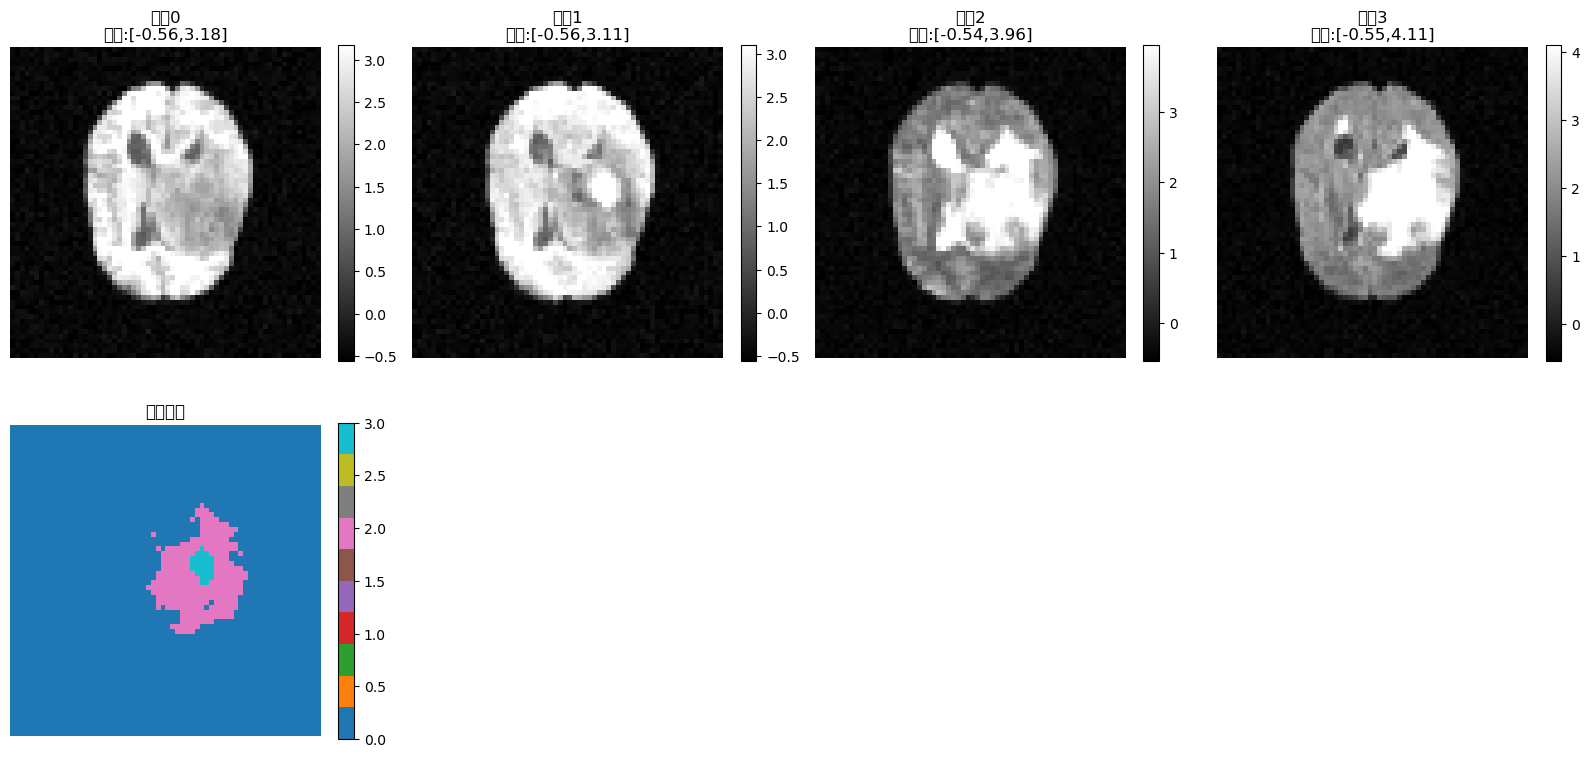

图像统计:
  整体范围: [-0.866, 5.532]
  整体均值: -0.000
标签唯一值: tensor([0, 1, 2, 3])


In [21]:
def test_data_augmentation():
    DATA_PATH = "D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
    
    case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]
    test_case = case_dirs[0]
    
    aug_dataset = BratsDataset(
        data_dir=DATA_PATH,
        case_dirs=[test_case],
        mode='train',
        patch_size=(64, 64, 64),
        transform=BratsTransform(p=1.0)
    )
    
    print("测试数据增强...")


DATA_PATH = "D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]

aug_dataset = BratsDataset(
    data_dir=DATA_PATH,
    case_dirs=[case_dirs[0]],
    mode='train',
    patch_size=(64, 64, 64),
    transform=BratsTransform(p=1.0)
)


###可视化
import matplotlib.pyplot as plt

img, seg = aug_dataset[0]
mid_slice = img.shape[1] // 2

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 显示4个模态
for i in range(4):
    slice_data = img[i, mid_slice].numpy()
    # 用百分比截断来增强对比度
    vmin = np.percentile(slice_data, 5)   # 去掉最低5%
    vmax = np.percentile(slice_data, 95)  # 去掉最高5%
    
    im = axes[0, i].imshow(slice_data, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f'模态{i}\n范围:[{vmin:.2f},{vmax:.2f}]')
    axes[0, i].axis('off')
    plt.colorbar(im, ax=axes[0, i], fraction=0.046)

# 显示分割标签
seg_slice = seg[mid_slice].numpy()
im2 = axes[1, 0].imshow(seg_slice, cmap='tab10', vmin=0, vmax=3)
axes[1, 0].set_title('分割标签')
axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

# 隐藏其他子图
for i in range(1, 4):
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 打印统计信息
print(f"图像统计:")
print(f"  整体范围: [{img.min():.3f}, {img.max():.3f}]")
print(f"  整体均值: {img.mean():.3f}")
print(f"标签唯一值: {torch.unique(seg)}")

In [22]:
img, seg = aug_dataset[0]
print(f"图像形状: {img.shape}")
print(f"图像值范围: [{img.min():.3f}, {img.max():.3f}]")
print(f"图像是否有NaN: {torch.isnan(img).any()}")
print(f"图像均值: {img.mean():.3f}")

# 检查一个模态的数据分布
mid_slice = img.shape[1] // 2
for i in range(4):
    slice_data = img[i, mid_slice].numpy()
    print(f"模态{i}切片 - 范围: [{slice_data.min():.3f}, {slice_data.max():.3f}], 均值: {slice_data.mean():.3f}")

图像形状: torch.Size([4, 64, 64, 64])
图像值范围: [-0.494, 5.128]
图像是否有NaN: False
图像均值: -0.000
模态0切片 - 范围: [-0.475, 3.531], 均值: 0.444
模态1切片 - 范围: [-0.472, 3.623], 均值: 0.463
模态2切片 - 范围: [-0.458, 5.112], 均值: 0.477
模态3切片 - 范围: [-0.453, 4.980], 均值: 0.496


In [23]:
from sklearn.model_selection import train_test_split
class CachedBratsDataset(BratsDataset):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.cache = {}
        self.loaded_data = {}  # 缓存已加载的原始数据

    def _load_and_preprocess(self, case_dir):
        """缓存加载和预处理结果"""
        if case_dir in self.loaded_data:
            return self.loaded_data[case_dir]

        files = self._find_modality_files(case_dir)

        # 加载所有模态
        modalities_data = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            data, affine = self._load_nifti(files[mod])
            data = self._normalize(data)
            modalities_data.append(data)

        # 加载分割标签
        seg_data, _ = self._load_nifti(files['seg'])
        seg_data = self._remap_seg_labels(seg_data)

        # 堆叠图像
        image = np.stack(modalities_data, axis=-1)

        # 调整尺寸
        if image.shape[:3] != self.patch_size:
            image = self._resize_volume(image, self.patch_size)
            seg_data = self._resize_volume(seg_data, self.patch_size, is_seg=True)

        result = (image, seg_data)
        self.loaded_data[case_dir] = result
        return result

    def __getitem__(self, idx):
        case_dir = self.case_dirs[idx]

        if idx in self.cache:
            image, seg_data = self.cache[idx]
        else:
            image, seg_data = self._load_and_preprocess(case_dir)
            self.cache[idx] = (image, seg_data)

        # 转换为PyTorch格式
        image = torch.from_numpy(image).permute(3, 2, 0, 1).float()
        seg_data = torch.from_numpy(seg_data).permute(2, 0, 1).long()

        # 数据增强
        if self.transform and self.mode == 'train':
            image, seg_data = self.transform(image, seg_data)

        return image, seg_data

# 使用缓存版本
DATA_PATH = "D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
case_dirs = [d for d in glob(os.path.join(DATA_PATH, "BraTS*")) if os.path.isdir(d)]
train_dirs, val_dirs = train_test_split(case_dirs, test_size=0.2, random_state=42)

print(f"训练集: {len(train_dirs)} 个病例")
print(f"验证集: {len(val_dirs)} 个病例")

train_dataset = CachedBratsDataset(
    data_dir="D:/brain_tumor_project/MICCAI_BraTS2020_TrainingData/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData",
    case_dirs=train_dirs,
    mode='train',
    patch_size=(96, 96, 96),
    transform=None  # 先关闭数据增强
)

训练集: 295 个病例
验证集: 74 个病例


In [24]:
# 先定义device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [30]:
import torch.nn.functional as nnF

class WeightedDiceCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        if class_weights is None:
            # 基于标签分布计算权重
            class_weights = torch.tensor([0.1, 10.0, 1.0, 2.0])  # 大幅提高类别1的权重
        self.class_weights = class_weights.to(device)
        self.dice_weight = 0.6
        self.ce_weight = 0.4

    def forward(self, pred, target):
        # 加权交叉熵损失
        ce_loss = nnF.cross_entropy(pred, target, weight=self.class_weights)

        # Dice损失
        dice_loss = 1 - dice_coefficient(pred, target).mean()

        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

# 使用加权损失
criterion = WeightedDiceCELoss()

In [31]:
class Conv3DBlock(nn.Module):
    """一个简单的3D卷积块：Conv3D -> BatchNorm -> ReLU"""
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class DoubleConv(nn.Module):
    """标准的双卷积层：ConvBlock -> ConvBlock"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            Conv3DBlock(in_channels, out_channels),
            Conv3DBlock(out_channels, out_channels)
        )

    def forward(self, x):
        return self.double_conv(x)

class Encoder(nn.Module):
    """UNet的编码器部分，负责特征提取和下采样"""
    def __init__(self, in_channels=1, base_channels=32):
        super().__init__()
        self.levels = nn.ModuleList()

        # 定义每个级别的输入输出通道数
        self.channels = [in_channels, base_channels, base_channels*2, base_channels*4, base_channels*8]

        # 创建4个下采样级别
        for i in range(len(self.channels)-1):
            self.levels.append(
                nn.Sequential(
                    DoubleConv(self.channels[i], self.channels[i+1]),
                    nn.MaxPool3d(2)  # 下采样
                )
            )

    def forward(self, x):
        features = []  # 保存每个级别的特征，用于跳跃连接
        current_x = x

        for level in self.levels:
            # 通过双卷积
            conv_output = level[0](current_x)
            features.append(conv_output)  # 保存卷积后的特征（在下采样之前）
            # 下采样
            current_x = level[1](conv_output)

        return features, current_x

class Decoder(nn.Module):
    """UNet的解码器部分，负责上采样和特征融合"""
    def __init__(self, base_channels=32, num_classes=3):
        super().__init__()
        self.up_convs = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        # 解码器的通道数序列（从深层到浅层）
        self.decoder_channels = [
            base_channels * 16,  # bottleneck输出
            base_channels * 8,   # 上采样后与编码器的base_channels*8拼接
            base_channels * 4,   # 上采样后与编码器的base_channels*4拼接
            base_channels * 2,   # 上采样后与编码器的base_channels*2拼接
        ]

        # 创建上采样路径
        for i in range(len(self.decoder_channels)-1):
            # 上采样层
            self.upsamples.append(
                nn.ConvTranspose3d(
                    self.decoder_channels[i],
                    self.decoder_channels[i] // 2,
                    kernel_size=2,
                    stride=2
                )
            )

            # 双卷积层：输入通道数 = 上采样输出 + 对应编码器特征的通道数
            in_ch = (self.decoder_channels[i] // 2) + (base_channels * 8 // (2 ** i))
            out_ch = self.decoder_channels[i+1]
            self.up_convs.append(DoubleConv(in_ch, out_ch))

        # 最终输出层
        self.final_conv = nn.Conv3d(base_channels * 2, num_classes, kernel_size=1)

    def forward(self, features, bottleneck):
        x = bottleneck

        # 反向遍历特征（从深层到浅层）
        for i, (upsample, up_conv) in enumerate(zip(self.upsamples, self.up_convs)):
            # 上采样
            x = upsample(x)

            # 获取对应的编码器特征（从后往前取）
            enc_feat = features[-(i+1)]

            # 调整特征尺寸（确保尺寸匹配）
            if x.shape != enc_feat.shape:
                x = center_crop_or_pad(x, enc_feat.shape[2:])

            # 跳跃连接：拼接编码器和解码器特征
            x = torch.cat([x, enc_feat], dim=1)
            x = up_conv(x)

        return self.final_conv(x)

def center_crop_or_pad(tensor, target_spatial_shape):
    """中心裁剪或填充张量到目标空间形状"""
    _, C, D, H, W = tensor.shape
    target_D, target_H, target_W = target_spatial_shape

    # 计算需要裁剪或填充的量
    diff_D = target_D - D
    diff_H = target_H - H
    diff_W = target_W - W

    if diff_D == 0 and diff_H == 0 and diff_W == 0:
        return tensor

    # 计算裁剪/填充的边界
    start_D = max(-diff_D // 2, 0)
    start_H = max(-diff_H // 2, 0)
    start_W = max(-diff_W // 2, 0)

    end_D = min(D, D - (diff_D + 1) // 2)
    end_H = min(H, H - (diff_H + 1) // 2)
    end_W = min(W, W - (diff_W + 1) // 2)

    # 先裁剪（如果需要）
    cropped = tensor[:, :, start_D:end_D, start_H:end_H, start_W:end_W]

    # 再填充（如果需要）
    if diff_D > 0 or diff_H > 0 or diff_W > 0:
        pad_D = (diff_D // 2, diff_D - diff_D // 2)
        pad_H = (diff_H // 2, diff_H - diff_H // 2)
        pad_W = (diff_W // 2, diff_W - diff_W // 2)
        cropped = F.pad(cropped, (pad_W[0], pad_W[1], pad_H[0], pad_H[1], pad_D[0], pad_D[1]))

    return cropped

In [32]:
class UNet3D(nn.Module):
    """完整的3D UNet模型 - 修复版本"""
    def __init__(self, in_channels=1, num_classes=3, base_channels=32):
        super().__init__()
        self.encoder = Encoder(in_channels, base_channels)
        self.bottleneck = DoubleConv(base_channels*8, base_channels*16)
        self.decoder = Decoder(base_channels, num_classes)

    def forward(self, x):
        # 保存输入尺寸用于最终上采样
        input_size = x.shape[2:]

        # 编码路径
        features, bottleneck = self.encoder(x)

        # 桥接层
        bottleneck = self.bottleneck(bottleneck)

        # 解码路径
        output = self.decoder(features, bottleneck)

        # 如果输出尺寸不等于输入尺寸，进行上采样
        if output.shape[2:] != input_size:
            output = torch.nn.functional.interpolate(output, size=input_size, mode='trilinear', align_corners=False)

        return output

In [33]:
def load_checkpoint_and_continue(model, optimizer, checkpoint_path):
    """加载检查点并继续训练"""
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_dice = checkpoint['best_val_dice']

    print(f"从epoch {start_epoch}恢复训练，最佳Dice: {best_val_dice:.4f}")
    return start_epoch, best_val_dice

In [34]:
def dice_coefficient(pred, target, smooth=1e-6):
    """简单的Dice系数计算 - 返回标量值"""
    pred = torch.softmax(pred, dim=1)

    dice_total = 0.0
    num_classes = pred.shape[1]

    # 计算每个类别的Dice并求和
    for class_idx in range(num_classes):
        pred_channel = pred[:, class_idx]
        target_channel = (target == class_idx).float()

        intersection = (pred_channel * target_channel).sum()
        union = pred_channel.sum() + target_channel.sum()

        dice = (2. * intersection + smooth) / (union + smooth)
        dice_total += dice

    # 返回所有类别的平均Dice
    return dice_total / num_classes

In [35]:
import torch.nn as nn
import torch.nn.functional as F

class DiceCELoss(nn.Module):
    """Dice损失 + CrossEntropy损失的组合"""
    def __init__(self, weight_ce=0.5, weight_dice=0.5):
        super().__init__()
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice
        self.ce = nn.CrossEntropyLoss()

    def forward(self, pred, target):
        # CrossEntropy损失
        ce_loss = self.ce(pred, target)

        # Dice损失 (1 - Dice系数)
        dice_loss = 1 - dice_coefficient(pred, target).mean()

        # 组合损失
        return self.weight_ce * ce_loss + self.weight_dice * dice_loss

In [36]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

# - optim.Adam: 自适应学习率优化器
# - ReduceLROnPlateau: 当验证损失停止改善时自动降低学习率

In [37]:
def create_brats_model():
    """创建适用于BraTS数据的4模态模型"""

    model = UNet3D(
        in_channels=4,      # 4个模态: t1, t1ce, t2, flair
        num_classes=4,      # 4个类别: 背景(0), 坏死(1), 水肿(2), 增强肿瘤(3)
        base_channels=32    # 基础通道数，控制模型大小
    )

    print("BraTS模型配置:")
    print(f"  输入通道: 4 (t1, t1ce, t2, flair)")
    print(f"  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)")
    print(f"  基础通道: 32")
    print(f"  参数量: {sum(p.numel() for p in model.parameters()):,}")

    return model

In [38]:
def calculate_class_weights(train_loader, num_classes=4):
    """计算基于训练数据的类别权重"""
    class_counts = torch.zeros(num_classes)
    total_samples = 0

    print("计算类别权重...")
    for data, target in train_loader:
        for class_idx in range(num_classes):
            class_counts[class_idx] += (target == class_idx).sum().item()
        total_samples += target.numel()

    class_weights = total_samples / (num_classes * class_counts)
    class_weights = class_weights / class_weights.sum()  # 归一化

    print("类别分布:")
    for i, (count, weight) in enumerate(zip(class_counts, class_weights)):
        names = {0: "背景", 1: "坏死", 2: "水肿", 3: "增强肿瘤"}
        print(f"  {names[i]}: {count:8d}体素, 权重: {weight:.4f}")

    return class_weights

In [39]:
# 创建数据加载器
print("创建数据加载器...")
train_loader, val_loader = create_brats_data_loaders()

# 检查数据加载器
print(f"训练集批次: {len(train_loader)}")
print(f"验证集批次: {len(val_loader)}")

创建数据加载器...
使用全部 369 个病例
训练集: 295 个病例
验证集: 74 个病例
训练batches: 148
验证batches: 74
训练集批次: 148
验证集批次: 74


In [40]:
class BalancedWeightedDiceCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        if class_weights is None:
            # 更平衡的权重
            class_weights = torch.tensor([0.3, 5.0, 1.0, 2.0])  # 调整
        self.register_buffer('class_weights', class_weights)
        self.dice_weight = 0.7
        self.ce_weight = 0.3

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

def setup_live_plotting():
    """设置实时绘图"""
    plt.ion()  # 开启交互模式
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    return fig, (ax1, ax2, ax3, ax4)

def update_live_plots(epoch, train_losses, val_losses, train_dices, val_dices, axes):
    """更新实时图表"""
    ax1, ax2, ax3, ax4 = axes

    # 清除旧图表
    for ax in [ax1, ax2, ax3, ax4]:
        ax.clear()

    epochs_range = range(1, len(train_losses) + 1)

    # 1. 损失曲线
    ax1.plot(epochs_range, train_losses, 'b-', label='训练损失', linewidth=2)
    ax1.plot(epochs_range, val_losses, 'r-', label='验证损失', linewidth=2)
    ax1.set_title('训练和验证损失')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('损失')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Dice系数曲线
    ax2.plot(epochs_range, train_dices, 'b-', label='训练Dice', linewidth=2)
    ax2.plot(epochs_range, val_dices, 'r-', label='验证Dice', linewidth=2)
    ax2.set_title('训练和验证Dice系数')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Dice系数')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)  # Dice范围0-1

    # 3. 学习率变化（如果记录了的话）
    if hasattr(update_live_plots, 'learning_rates'):
        ax3.plot(epochs_range, update_live_plots.learning_rates, 'g-', linewidth=2)
        ax3.set_title('学习率变化')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('学习率')
        ax3.set_yscale('log')
        ax3.grid(True, alpha=0.3)
    else:
        update_live_plots.learning_rates = []
        ax3.text(0.5, 0.5, '学习率数据待更新', ha='center', va='center', transform=ax3.transAxes)

    # 4. 训练进度和统计
    current_epoch = len(train_losses)
    ax4.axis('off')
    stats_text = f"""
    训练进度:
    • 当前Epoch: {current_epoch}
    • 最佳验证Dice: {max(val_dices) if val_dices else 0:.4f}
    • 最新训练Dice: {train_dices[-1] if train_dices else 0:.4f}
    • 最新验证Dice: {val_dices[-1] if val_dices else 0:.4f}
    • 早停计数: {getattr(update_live_plots, 'no_improve_count', 0)}
    """
    ax4.text(0.1, 0.9, stats_text, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

    plt.tight_layout()
    plt.draw()
    plt.pause(0.1)  # 短暂暂停以更新图表

In [42]:
def check_saved_files():
    """检查保存的文件"""
    checkpoint_dir = "D:/brain_tumor_project/BraTS_Checkpoints"

    if os.path.exists(checkpoint_dir):
        files = os.listdir(checkpoint_dir)
        print("检查点文件:")
        for file in files:
            file_path = os.path.join(checkpoint_dir, file)
            size = os.path.getsize(file_path) / (1024*1024)  # MB
            print(f"  {file} ({size:.1f} MB)")
    else:
        print("检查点目录不存在")
check_saved_files()

检查点文件:
  .ipynb_checkpoints (0.0 MB)
  best_model.pth (257.4 MB)
  checkpoint_epoch_10.pth (257.4 MB)
  checkpoint_epoch_15.pth (257.4 MB)
  checkpoint_epoch_20.pth (257.4 MB)
  checkpoint_epoch_25.pth (257.4 MB)
  checkpoint_epoch_5.pth (257.4 MB)


In [43]:
def main_training_with_visualization(resume_from_checkpoint):
    """带可视化的主训练函数"""
    # 设备配置
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")

    checkpoint_dir = "D:/brain_tumor_project/BraTS_Checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"检查点保存路径: {checkpoint_dir}")

    # 设置实时绘图
    fig, axes = setup_live_plotting()

    # 创建模型
    model = create_brats_model().to(device)

    # 定义优化器和损失函数
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # === 只修改这一行：使用简单的肿瘤聚焦损失 ===
    class TumorFocusedLoss(nn.Module):
        def __init__(self):
            super().__init__()

        def forward(self, pred, target):
            smooth = 1e-6
            pred = torch.softmax(pred, dim=1)

            # 创建肿瘤mask（所有非背景区域）
            tumor_mask = (target > 0).float()

            # 只计算肿瘤区域的损失
            pred_tumor = pred[:, 1:].sum(dim=1)  # 所有肿瘤类别的概率和
            target_tumor = tumor_mask

            intersection = (pred_tumor * target_tumor).sum()
            union = pred_tumor.sum() + target_tumor.sum()

            dice = (2. * intersection + smooth) / (union + smooth)
            return 1 - dice  # 只优化肿瘤检测

    # 学习率调整 + 损失函数微调
    criterion = WeightedDiceCELoss(class_weights=torch.tensor([0.2, 6.0, 1.0, 2.5]))

    # 训练参数
    num_epochs = 100
    best_val_dice = 0.0

    # 早停参数
    early_stop_patience = 10
    early_stop_delta = 0.001
    no_improve_count = 0

    # 创建检查点目录
    os.makedirs(checkpoint_dir, exist_ok=True)

    # 恢复训练逻辑
    start_epoch = 0
    train_losses, val_losses = [], []
    train_dices, val_dices = [], []
    learning_rates = []

    if resume_from_checkpoint and os.path.exists(resume_from_checkpoint):
        print(f"从检查点恢复训练: {resume_from_checkpoint}")
        checkpoint = torch.load(resume_from_checkpoint)

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        # 小幅降低学习率，追求更稳定收敛
        for param_group in optimizer.param_groups:
            param_group['lr'] = 6e-5
        print("学习率调整为: 6e-5")

        start_epoch = checkpoint['epoch'] + 1
        best_val_dice = checkpoint['best_val_dice']
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
        train_dices = checkpoint['train_dices']
        val_dices = checkpoint['val_dices']

        print(f"恢复从 epoch {start_epoch} 开始，最佳Dice: {best_val_dice:.4f}")

    print(f"\n开始训练，最多 {num_epochs} 个epochs")
    print(f"早停机制: 连续 {early_stop_patience} 个epochs改善小于 {early_stop_delta} 时停止")
    print("=" * 60)

    # 记录训练过程
    learning_rates = []

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # === 训练阶段 ===
        model.train()
        train_loss = 0.0
        train_dice = 0.0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5

            if total_norm > 1000:  # 梯度太大了！
                print(f"梯度爆炸警告: {total_norm}")

            optimizer.step()

            dice = dice_coefficient(output, target).mean()

            train_loss += loss.item()
            train_dice += dice.item()

            if batch_idx % 20 == 0:
                print(f'  Batch {batch_idx:3d}/{len(train_loader)}, Loss: {loss.item():.4f}, Dice: {dice.item():.4f}')

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_dice = train_dice / len(train_loader)
        train_losses.append(epoch_train_loss)
        train_dices.append(epoch_train_dice)

        # === 验证阶段 ===
        model.eval()
        val_loss = 0.0
        val_dice = 0.0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                dice = dice_coefficient(output, target).mean()

                val_loss += loss.item()
                val_dice += dice.item()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_dice = val_dice / len(val_loader)
        val_losses.append(epoch_val_loss)
        val_dices.append(epoch_val_dice)

        # 记录学习率
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)
        update_live_plots.learning_rates = learning_rates

        # 更新实时图表
        update_live_plots(epoch, train_losses, val_losses, train_dices, val_dices, axes)

        # 早停逻辑
        improvement = epoch_val_dice - best_val_dice
        update_live_plots.no_improve_count = no_improve_count

        if improvement > early_stop_delta:
            best_val_dice = epoch_val_dice
            no_improve_count = 0

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_dice': best_val_dice,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_dices': train_dices,
                'val_dices': val_dices,
                'learning_rates': learning_rates
            }
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'best_model.pth'))
            print(f"保存最佳模型，验证Dice: {best_val_dice:.4f} (+{improvement:.4f})")

        else:
            no_improve_count += 1
            print(f"无显著改善，计数: {no_improve_count}/{early_stop_patience}")

            if no_improve_count >= early_stop_patience:
                print(f"触发早停：连续 {early_stop_patience} 个epochs无显著改善")
                break

        # 调整学习率
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(epoch_val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        if new_lr < old_lr:
            print(f"学习率从 {old_lr:.2e} 降低到 {new_lr:.2e}")

        epoch_time = time.time() - epoch_start
        print(f"训练 - Loss: {epoch_train_loss:.4f}, Dice: {epoch_train_dice:.4f}")
        print(f"验证 - Loss: {epoch_val_loss:.4f}, Dice: {epoch_val_dice:.4f}")
        print(f"时间: {epoch_time:.1f}s")

        if (epoch + 1) % 5 == 0:  # 每5个epoch保存一次
            checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_dice': best_val_dice,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_dices': train_dices,
                'val_dices': val_dices,
                'learning_rates': learning_rates
            }
            torch.save(checkpoint, checkpoint_path)
            print(f"检查点已保存到Google Drive: {checkpoint_path}")
            print(f"\n生成分割效果示意图 (Epoch {epoch+1})...")
            try:
                seg_fig = visualize_segmentation(model, val_loader, device, num_samples=2)
                seg_fig.savefig(f'/content/drive/MyDrive/BraTS_Checkpoints/segmentation_epoch_{epoch+1}.png',
                              dpi=150, bbox_inches='tight')
                plt.close(seg_fig)
                print(f" 分割示意图已保存")
            except Exception as e:
                print(f" 分割可视化失败: {e}")

        # 最佳模型也保存到Google Drive
        if epoch_val_dice > best_val_dice + early_stop_delta:
            best_checkpoint_path = os.path.join(checkpoint_dir, 'best_model.pth')
            torch.save(checkpoint, best_checkpoint_path)
            print(f"最佳模型已保存到Google Drive: {best_checkpoint_path}")

    # 训练结束后保存最终图表
    plt.savefig('/content/training_curves.png', dpi=300, bbox_inches='tight')
    print("训练曲线已保存为 /content/training_curves.png")

    total_time = time.time() - start_time
    actual_epochs = epoch + 1

    print(f"\n训练完成! 实际运行 {actual_epochs} 个epochs")
    print(f"总时间: {total_time/60:.1f}分钟")
    print(f"最佳验证Dice: {best_val_dice:.4f}")

    plt.ioff()  # 关闭交互模式
    plt.show()  # 显示最终图表

    return model, train_losses, val_losses, train_dices, val_dices

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_segmentation(model, dataloader, device, num_samples=3):
    """可视化分割结果"""
    model.eval()

    # 获取几个样本
    samples = []
    for i, (data, target) in enumerate(dataloader):
        if i >= num_samples:
            break
        samples.append((data, target))

    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    colors = ['black', 'red', 'green', 'blue']  # 背景, 坏死, 水肿, 增强肿瘤

    with torch.no_grad():
        for i, (data, target) in enumerate(samples):
            data, target = data.to(device), target.to(device)
            output = model(data)
            prediction = torch.softmax(output, dim=1)
            pred_mask = torch.argmax(prediction, dim=1)

            # 获取中间切片
            slice_idx = data.shape[2] // 2  # 深度方向的中间切片

            # 原始图像 (FLAIR模态)
            original_slice = data[0, 3, slice_idx].cpu().numpy()  # FLAIR是第4个模态

            # 真实标签
            gt_slice = target[0, slice_idx].cpu().numpy()

            # 预测结果
            pred_slice = pred_mask[0, slice_idx].cpu().numpy()

            # 置信度 (肿瘤类别的最大概率)
            confidence_slice = prediction[0, 1:4, slice_idx].max(dim=0)[0].cpu().numpy()

            # 绘制结果
            axes[i, 0].imshow(original_slice, cmap='gray')
            axes[i, 0].set_title('原始图像 (FLAIR)')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(original_slice, cmap='gray')
            axes[i, 1].imshow(gt_slice, cmap='tab10', alpha=0.5, vmin=0, vmax=3)
            axes[i, 1].set_title('真实分割')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(original_slice, cmap='gray')
            axes[i, 2].imshow(pred_slice, cmap='tab10', alpha=0.5, vmin=0, vmax=3)
            axes[i, 2].set_title('预测分割')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(confidence_slice, cmap='hot', vmin=0, vmax=1)
            axes[i, 3].set_title('预测置信度')
            axes[i, 3].axis('off')

            # 重叠比较
            axes[i, 4].imshow(original_slice, cmap='gray')
            # 用不同颜色显示正确和错误的分割
            correct_mask = (pred_slice == gt_slice) & (gt_slice > 0)  # 正确预测的肿瘤区域
            wrong_mask = (pred_slice != gt_slice) & (gt_slice > 0)    # 错误预测的肿瘤区域
            false_positive = (pred_slice > 0) & (gt_slice == 0)       # 假阳性

            # 创建彩色叠加
            overlay = np.zeros((*pred_slice.shape, 3))
            overlay[correct_mask] = [0, 1, 0]   # 绿色：正确
            overlay[wrong_mask] = [1, 0, 0]     # 红色：错误
            overlay[false_positive] = [1, 1, 0] # 黄色：假阳性

            axes[i, 4].imshow(overlay, alpha=0.6)
            axes[i, 4].set_title('正确(绿)/错误(红)/假阳性(黄)')
            axes[i, 4].axis('off')

    plt.tight_layout()
    return fig

创建数据加载器...
使用全部 369 个病例
训练集: 295 个病例
验证集: 74 个病例
训练batches: 148
验证batches: 74

开始带实时可视化的FA-UNet训练
使用设备: cuda
检查点保存路径: D:/brain_tumor_project/BraTS_Checkpoints
BraTS模型配置:
  输入通道: 4 (t1, t1ce, t2, flair)
  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)
  基础通道: 32
  参数量: 22,484,484

开始训练，最多 100 个epochs
早停机制: 连续 10 个epochs改善小于 0.001 时停止

Epoch 1/100
  Batch   0/148, Loss: 1.1779, Dice: 0.0930
  Batch  20/148, Loss: 0.9330, Dice: 0.1401
  Batch  40/148, Loss: 0.8933, Dice: 0.1485
  Batch  60/148, Loss: 0.8623, Dice: 0.1561
  Batch  80/148, Loss: 0.8081, Dice: 0.1707
  Batch 100/148, Loss: 0.8006, Dice: 0.1694
  Batch 120/148, Loss: 0.8021, Dice: 0.1716
  Batch 140/148, Loss: 0.7467, Dice: 0.1949


C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 39564 (\

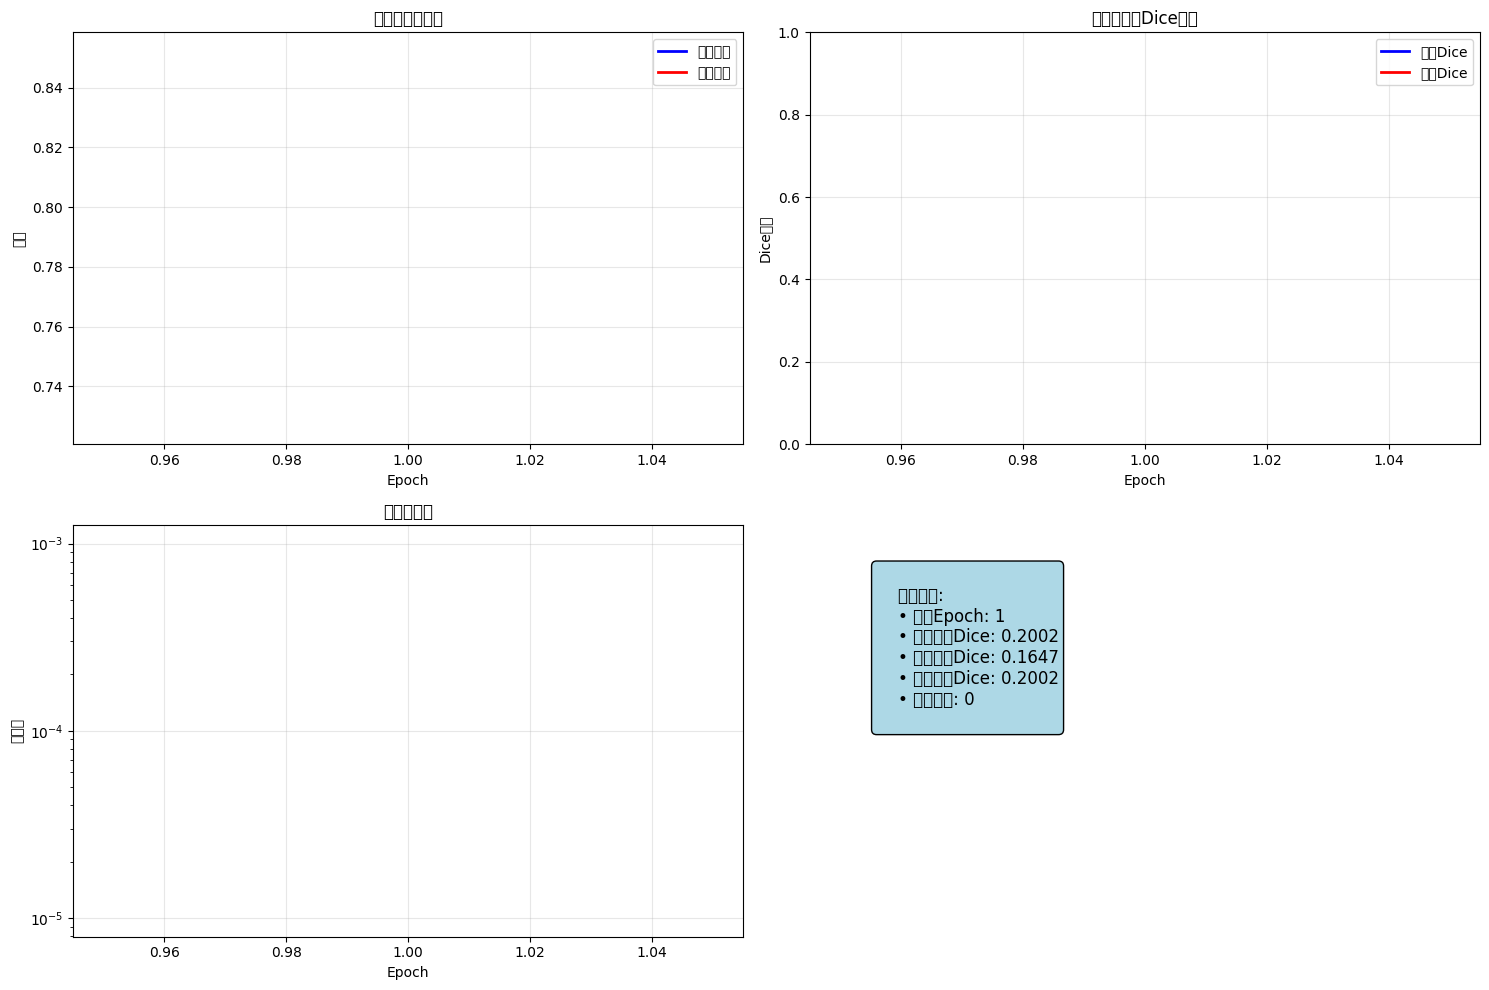

保存最佳模型，验证Dice: 0.2002 (+0.2002)
训练 - Loss: 0.8523, Dice: 0.1647
验证 - Loss: 0.7268, Dice: 0.2002
时间: 1366.9s

Epoch 2/100
  Batch   0/148, Loss: 0.7384, Dice: 0.1972
  Batch  20/148, Loss: 0.7288, Dice: 0.2079
  Batch  40/148, Loss: 0.7213, Dice: 0.2047
  Batch  60/148, Loss: 0.7351, Dice: 0.2157
  Batch  80/148, Loss: 0.7127, Dice: 0.1929
  Batch 100/148, Loss: 0.6917, Dice: 0.2287
  Batch 120/148, Loss: 0.6484, Dice: 0.2258
  Batch 140/148, Loss: 0.6581, Dice: 0.2222


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.2244 (+0.0242)
训练 - Loss: 0.6990, Dice: 0.2086
验证 - Loss: 0.6576, Dice: 0.2244
时间: 1433.2s

Epoch 3/100
  Batch   0/148, Loss: 0.6448, Dice: 0.2282
  Batch  20/148, Loss: 0.6802, Dice: 0.2391
  Batch  40/148, Loss: 0.6297, Dice: 0.2234
  Batch  60/148, Loss: 0.6175, Dice: 0.2445
  Batch  80/148, Loss: 0.6097, Dice: 0.2203
  Batch 100/148, Loss: 0.5912, Dice: 0.2297
  Batch 120/148, Loss: 0.5974, Dice: 0.2446
  Batch 140/148, Loss: 0.6105, Dice: 0.2602


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.2481 (+0.0236)
训练 - Loss: 0.6137, Dice: 0.2400
验证 - Loss: 0.5979, Dice: 0.2481
时间: 1275.8s

Epoch 4/100
  Batch   0/148, Loss: 0.6035, Dice: 0.2263
  Batch  20/148, Loss: 0.5794, Dice: 0.2630
  Batch  40/148, Loss: 0.5438, Dice: 0.2687
  Batch  60/148, Loss: 0.5642, Dice: 0.2629
  Batch  80/148, Loss: 0.5537, Dice: 0.3026
  Batch 100/148, Loss: 0.5495, Dice: 0.2376
  Batch 120/148, Loss: 0.5062, Dice: 0.3183
  Batch 140/148, Loss: 0.5249, Dice: 0.2862


...

<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.3002 (+0.0140)
训练 - Loss: 0.5073, Dice: 0.3005
验证 - Loss: 0.5095, Dice: 0.3002
时间: 1267.6s
检查点已保存到Google Drive: D:/brain_tumor_project/BraTS_Checkpoints\checkpoint_epoch_5.pth

生成分割效果示意图 (Epoch 5)...


C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2432653818.py:79: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2432653818.py:79: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2432653818.py:79: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2432653818.py:79: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2432653818.py:79: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2432653818.py:79: UserWarning: Glyph 23454 (\

 分割可视化失败: [Errno 2] No such file or directory: '/content/drive/MyDrive/BraTS_Checkpoints/segmentation_epoch_5.png'

Epoch 6/100
  Batch   0/148, Loss: 0.4686, Dice: 0.3165
  Batch  20/148, Loss: 0.5027, Dice: 0.2829
  Batch  40/148, Loss: 0.5177, Dice: 0.2626
  Batch  60/148, Loss: 0.4735, Dice: 0.2943
  Batch  80/148, Loss: 0.4633, Dice: 0.3154
  Batch 100/148, Loss: 0.4349, Dice: 0.4186
  Batch 120/148, Loss: 0.4341, Dice: 0.3621
  Batch 140/148, Loss: 0.5196, Dice: 0.3889


C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Linda\AppData\Local\Temp\ipykernel_20996\2519997954.py:65: UserWarning: Glyph 23454 (\

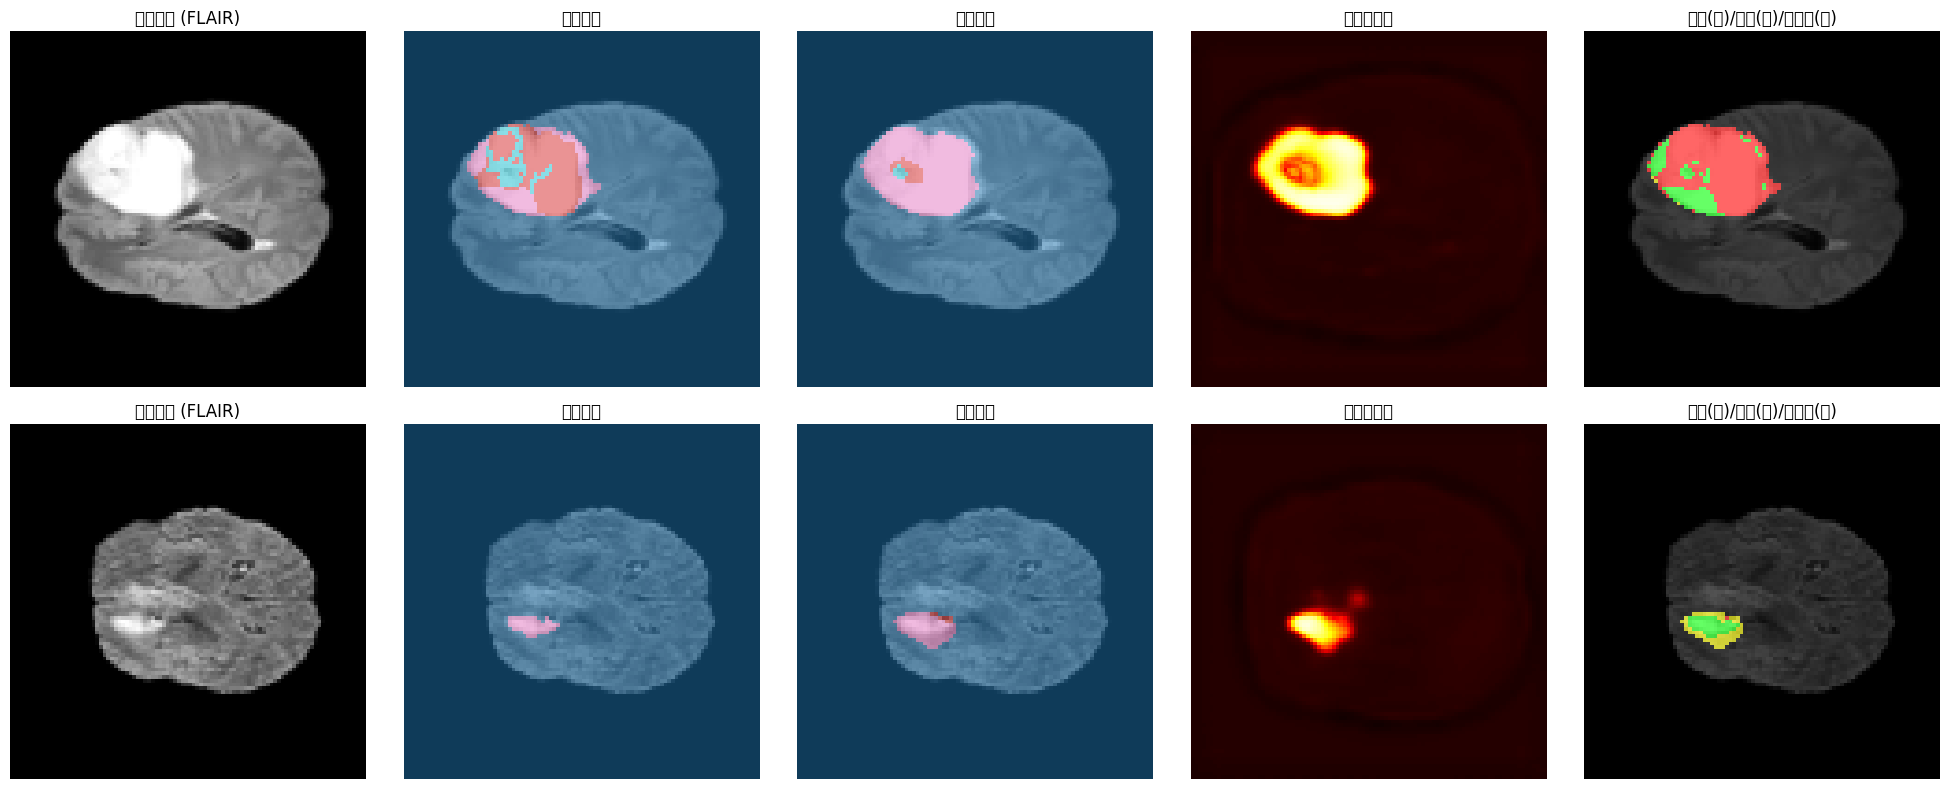

保存最佳模型，验证Dice: 0.3445 (+0.0443)
训练 - Loss: 0.4663, Dice: 0.3380
验证 - Loss: 0.4534, Dice: 0.3445
时间: 1260.7s

Epoch 7/100
  Batch   0/148, Loss: 0.4330, Dice: 0.3703
  Batch  20/148, Loss: 0.4210, Dice: 0.3982
  Batch  40/148, Loss: 0.4889, Dice: 0.3130
  Batch  60/148, Loss: 0.3586, Dice: 0.4770
  Batch  80/148, Loss: 0.4609, Dice: 0.4006
  Batch 100/148, Loss: 0.3915, Dice: 0.4225
  Batch 120/148, Loss: 0.3924, Dice: 0.4195
  Batch 140/148, Loss: 0.4182, Dice: 0.4169


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.3983 (+0.0538)
训练 - Loss: 0.4298, Dice: 0.3797
验证 - Loss: 0.4198, Dice: 0.3983
时间: 1259.4s

Epoch 8/100
  Batch   0/148, Loss: 0.4289, Dice: 0.3551
  Batch  20/148, Loss: 0.3649, Dice: 0.4512
  Batch  40/148, Loss: 0.3951, Dice: 0.3940
  Batch  60/148, Loss: 0.3630, Dice: 0.4642
  Batch  80/148, Loss: 0.3979, Dice: 0.3875
  Batch 100/148, Loss: 0.3811, Dice: 0.4919
  Batch 120/148, Loss: 0.4934, Dice: 0.3556
  Batch 140/148, Loss: 0.3535, Dice: 0.4641


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.4272 (+0.0289)
训练 - Loss: 0.3920, Dice: 0.4307
验证 - Loss: 0.4047, Dice: 0.4272
时间: 1256.7s

Epoch 9/100
  Batch   0/148, Loss: 0.3636, Dice: 0.4439
  Batch  20/148, Loss: 0.3719, Dice: 0.4410
  Batch  40/148, Loss: 0.3063, Dice: 0.5363
  Batch  60/148, Loss: 0.3021, Dice: 0.5766
  Batch  80/148, Loss: 0.3910, Dice: 0.3803
  Batch 100/148, Loss: 0.3720, Dice: 0.4488
  Batch 120/148, Loss: 0.3714, Dice: 0.4168
  Batch 140/148, Loss: 0.3002, Dice: 0.5821


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.4300 (+0.0028)
训练 - Loss: 0.3579, Dice: 0.4806
验证 - Loss: 0.3996, Dice: 0.4300
时间: 1317.4s

Epoch 10/100
  Batch   0/148, Loss: 0.3261, Dice: 0.5136
  Batch  20/148, Loss: 0.3215, Dice: 0.5151
  Batch  40/148, Loss: 0.2820, Dice: 0.6005
  Batch  60/148, Loss: 0.2970, Dice: 0.5398
  Batch  80/148, Loss: 0.3611, Dice: 0.4371
  Batch 100/148, Loss: 0.3439, Dice: 0.5075
  Batch 120/148, Loss: 0.2784, Dice: 0.5698
  Batch 140/148, Loss: 0.3229, Dice: 0.5214


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.5259 (+0.0959)
训练 - Loss: 0.3239, Dice: 0.5347
验证 - Loss: 0.3510, Dice: 0.5259
时间: 1282.7s
检查点已保存到Google Drive: D:/brain_tumor_project/BraTS_Checkpoints\checkpoint_epoch_10.pth

生成分割效果示意图 (Epoch 10)...
 分割可视化失败: [Errno 2] No such file or directory: '/content/drive/MyDrive/BraTS_Checkpoints/segmentation_epoch_10.png'

Epoch 11/100
  Batch   0/148, Loss: 0.2756, Dice: 0.5944
  Batch  20/148, Loss: 0.2212, Dice: 0.6795
  Batch  40/148, Loss: 0.2515, Dice: 0.6140
  Batch  60/148, Loss: 0.2293, Dice: 0.6626
  Batch  80/148, Loss: 0.2297, Dice: 0.6570
  Batch 100/148, Loss: 0.2502, Dice: 0.6258
  Batch 120/148, Loss: 0.3197, Dice: 0.5694
  Batch 140/148, Loss: 0.2744, Dice: 0.5796


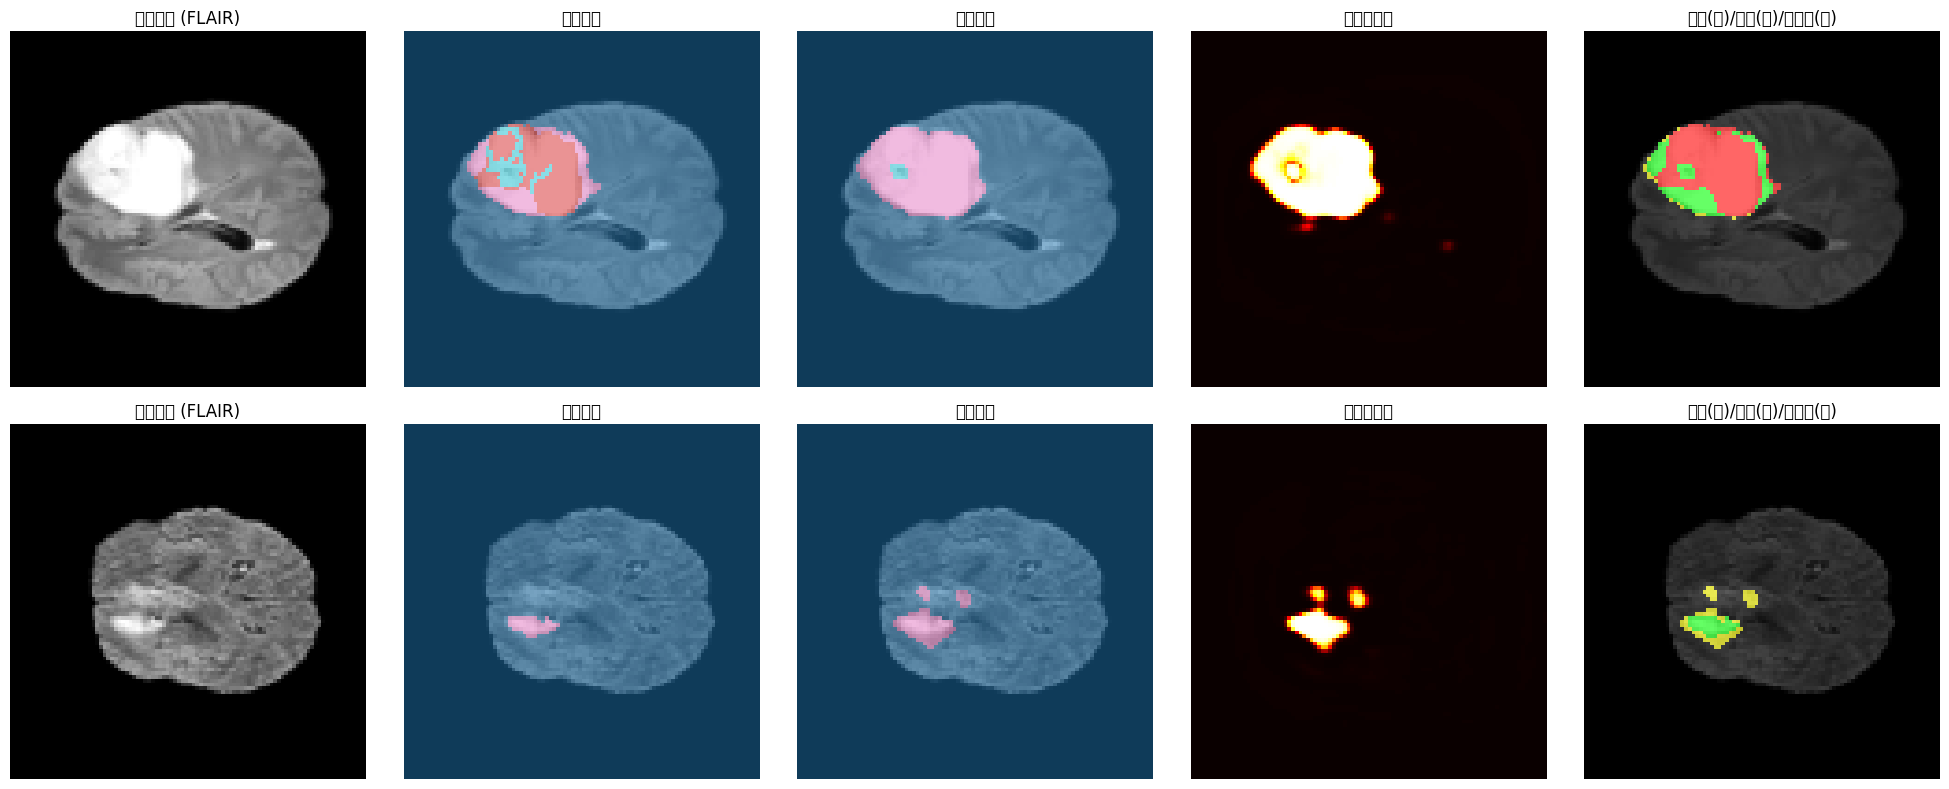

保存最佳模型，验证Dice: 0.5689 (+0.0431)
训练 - Loss: 0.2915, Dice: 0.5855
验证 - Loss: 0.3240, Dice: 0.5689
时间: 1268.3s

Epoch 12/100
  Batch   0/148, Loss: 0.3011, Dice: 0.5474
  Batch  20/148, Loss: 0.2876, Dice: 0.5964
  Batch  40/148, Loss: 0.3065, Dice: 0.5594
  Batch  60/148, Loss: 0.2595, Dice: 0.6334
  Batch  80/148, Loss: 0.2881, Dice: 0.5900
  Batch 100/148, Loss: 0.2814, Dice: 0.6000
  Batch 120/148, Loss: 0.3011, Dice: 0.5391
  Batch 140/148, Loss: 0.1857, Dice: 0.7261


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.5979 (+0.0290)
训练 - Loss: 0.2636, Dice: 0.6310
验证 - Loss: 0.2910, Dice: 0.5979
时间: 1263.2s

Epoch 13/100
  Batch   0/148, Loss: 0.2205, Dice: 0.6991
  Batch  20/148, Loss: 0.1651, Dice: 0.7771
  Batch  40/148, Loss: 0.2624, Dice: 0.6047
  Batch  60/148, Loss: 0.1762, Dice: 0.7650
  Batch  80/148, Loss: 0.2385, Dice: 0.6260
  Batch 100/148, Loss: 0.2352, Dice: 0.6311
  Batch 120/148, Loss: 0.2024, Dice: 0.7563
  Batch 140/148, Loss: 0.2436, Dice: 0.6318


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.6033 (+0.0054)
训练 - Loss: 0.2465, Dice: 0.6626
验证 - Loss: 0.2945, Dice: 0.6033
时间: 1266.4s

Epoch 14/100
  Batch   0/148, Loss: 0.2479, Dice: 0.6445
  Batch  20/148, Loss: 0.1821, Dice: 0.7663
  Batch  40/148, Loss: 0.2278, Dice: 0.6651
  Batch  60/148, Loss: 0.2355, Dice: 0.6718
  Batch  80/148, Loss: 0.2041, Dice: 0.7560
  Batch 100/148, Loss: 0.2301, Dice: 0.6942
  Batch 120/148, Loss: 0.2157, Dice: 0.7455
  Batch 140/148, Loss: 0.1419, Dice: 0.8083


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.6241 (+0.0208)
训练 - Loss: 0.2364, Dice: 0.6831
验证 - Loss: 0.2735, Dice: 0.6241
时间: 1256.5s

Epoch 15/100
  Batch   0/148, Loss: 0.1915, Dice: 0.7284
  Batch  20/148, Loss: 0.2748, Dice: 0.6467
  Batch  40/148, Loss: 0.2177, Dice: 0.7168
  Batch  60/148, Loss: 0.4662, Dice: 0.4893
  Batch  80/148, Loss: 0.1657, Dice: 0.7548
  Batch 100/148, Loss: 0.1322, Dice: 0.8160
  Batch 120/148, Loss: 0.1608, Dice: 0.7787
  Batch 140/148, Loss: 0.1779, Dice: 0.7445


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.6447 (+0.0206)
训练 - Loss: 0.2196, Dice: 0.7055
验证 - Loss: 0.2646, Dice: 0.6447
时间: 1259.2s
检查点已保存到Google Drive: D:/brain_tumor_project/BraTS_Checkpoints\checkpoint_epoch_15.pth

生成分割效果示意图 (Epoch 15)...
 分割可视化失败: [Errno 2] No such file or directory: '/content/drive/MyDrive/BraTS_Checkpoints/segmentation_epoch_15.png'

Epoch 16/100
  Batch   0/148, Loss: 0.2614, Dice: 0.6081
  Batch  20/148, Loss: 0.1678, Dice: 0.7484
  Batch  40/148, Loss: 0.2922, Dice: 0.5278
  Batch  60/148, Loss: 0.2270, Dice: 0.6928
  Batch  80/148, Loss: 0.2244, Dice: 0.7774
  Batch 100/148, Loss: 0.2521, Dice: 0.6426
  Batch 120/148, Loss: 0.2582, Dice: 0.6571
  Batch 140/148, Loss: 0.1302, Dice: 0.8114


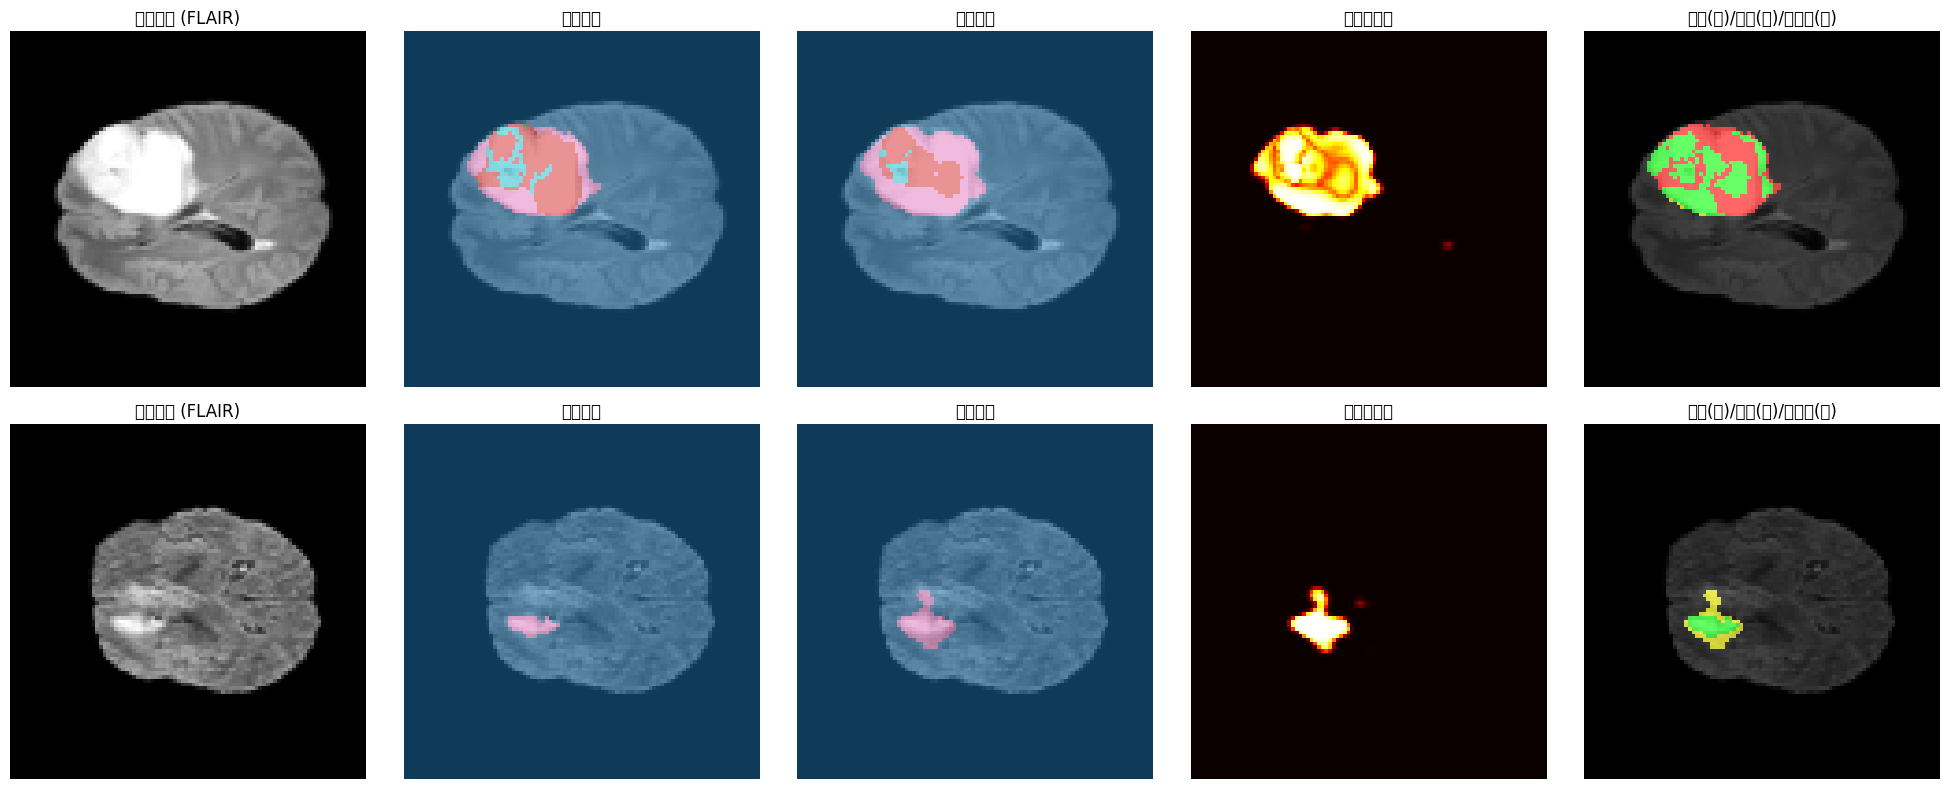

保存最佳模型，验证Dice: 0.6732 (+0.0285)
训练 - Loss: 0.2060, Dice: 0.7259
验证 - Loss: 0.2466, Dice: 0.6732
时间: 1265.3s

Epoch 17/100
  Batch   0/148, Loss: 0.1984, Dice: 0.7377
  Batch  20/148, Loss: 0.1421, Dice: 0.8083
  Batch  40/148, Loss: 0.1698, Dice: 0.7857
  Batch  60/148, Loss: 0.1711, Dice: 0.7701
  Batch  80/148, Loss: 0.2290, Dice: 0.6364
  Batch 100/148, Loss: 0.1894, Dice: 0.7648
  Batch 120/148, Loss: 0.1802, Dice: 0.7594
  Batch 140/148, Loss: 0.2555, Dice: 0.7079


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.6797 (+0.0065)
训练 - Loss: 0.1974, Dice: 0.7370
验证 - Loss: 0.2511, Dice: 0.6797
时间: 1266.3s

Epoch 18/100
  Batch   0/148, Loss: 0.1783, Dice: 0.7619
  Batch  20/148, Loss: 0.1399, Dice: 0.7998
  Batch  40/148, Loss: 0.1816, Dice: 0.7414
  Batch  60/148, Loss: 0.2165, Dice: 0.6921
  Batch  80/148, Loss: 0.2068, Dice: 0.7524
  Batch 100/148, Loss: 0.2664, Dice: 0.7145
  Batch 120/148, Loss: 0.1640, Dice: 0.7464
  Batch 140/148, Loss: 0.1149, Dice: 0.8388


<Figure size 640x480 with 0 Axes>

无显著改善，计数: 1/10
训练 - Loss: 0.1950, Dice: 0.7457
验证 - Loss: 0.2495, Dice: 0.6776
时间: 1266.6s

Epoch 19/100
  Batch   0/148, Loss: 0.2899, Dice: 0.5585
  Batch  20/148, Loss: 0.1288, Dice: 0.8298
  Batch  40/148, Loss: 0.1491, Dice: 0.7818
  Batch  60/148, Loss: 0.1445, Dice: 0.7897
  Batch  80/148, Loss: 0.2152, Dice: 0.6926
  Batch 100/148, Loss: 0.1330, Dice: 0.8214
  Batch 120/148, Loss: 0.2063, Dice: 0.7229
  Batch 140/148, Loss: 0.1178, Dice: 0.8384


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.6941 (+0.0145)
训练 - Loss: 0.1870, Dice: 0.7528
验证 - Loss: 0.2347, Dice: 0.6941
时间: 1306.5s

Epoch 20/100
  Batch   0/148, Loss: 0.1598, Dice: 0.7704
  Batch  20/148, Loss: 0.2260, Dice: 0.7310
  Batch  40/148, Loss: 0.1405, Dice: 0.8027
  Batch  60/148, Loss: 0.1643, Dice: 0.7878
  Batch  80/148, Loss: 0.1781, Dice: 0.7832
  Batch 100/148, Loss: 0.1836, Dice: 0.7421
  Batch 120/148, Loss: 0.1853, Dice: 0.7909
  Batch 140/148, Loss: 0.1347, Dice: 0.8009


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.6973 (+0.0031)
训练 - Loss: 0.1804, Dice: 0.7618
验证 - Loss: 0.2353, Dice: 0.6973
时间: 1308.8s
检查点已保存到Google Drive: D:/brain_tumor_project/BraTS_Checkpoints\checkpoint_epoch_20.pth

生成分割效果示意图 (Epoch 20)...
 分割可视化失败: [Errno 2] No such file or directory: '/content/drive/MyDrive/BraTS_Checkpoints/segmentation_epoch_20.png'

Epoch 21/100
  Batch   0/148, Loss: 0.1310, Dice: 0.8275
  Batch  20/148, Loss: 0.2951, Dice: 0.7283
  Batch  40/148, Loss: 0.1952, Dice: 0.7642
  Batch  60/148, Loss: 0.1356, Dice: 0.8225
  Batch  80/148, Loss: 0.1474, Dice: 0.7787
  Batch 100/148, Loss: 0.4794, Dice: 0.6499
  Batch 120/148, Loss: 0.2894, Dice: 0.6204
  Batch 140/148, Loss: 0.2042, Dice: 0.7264


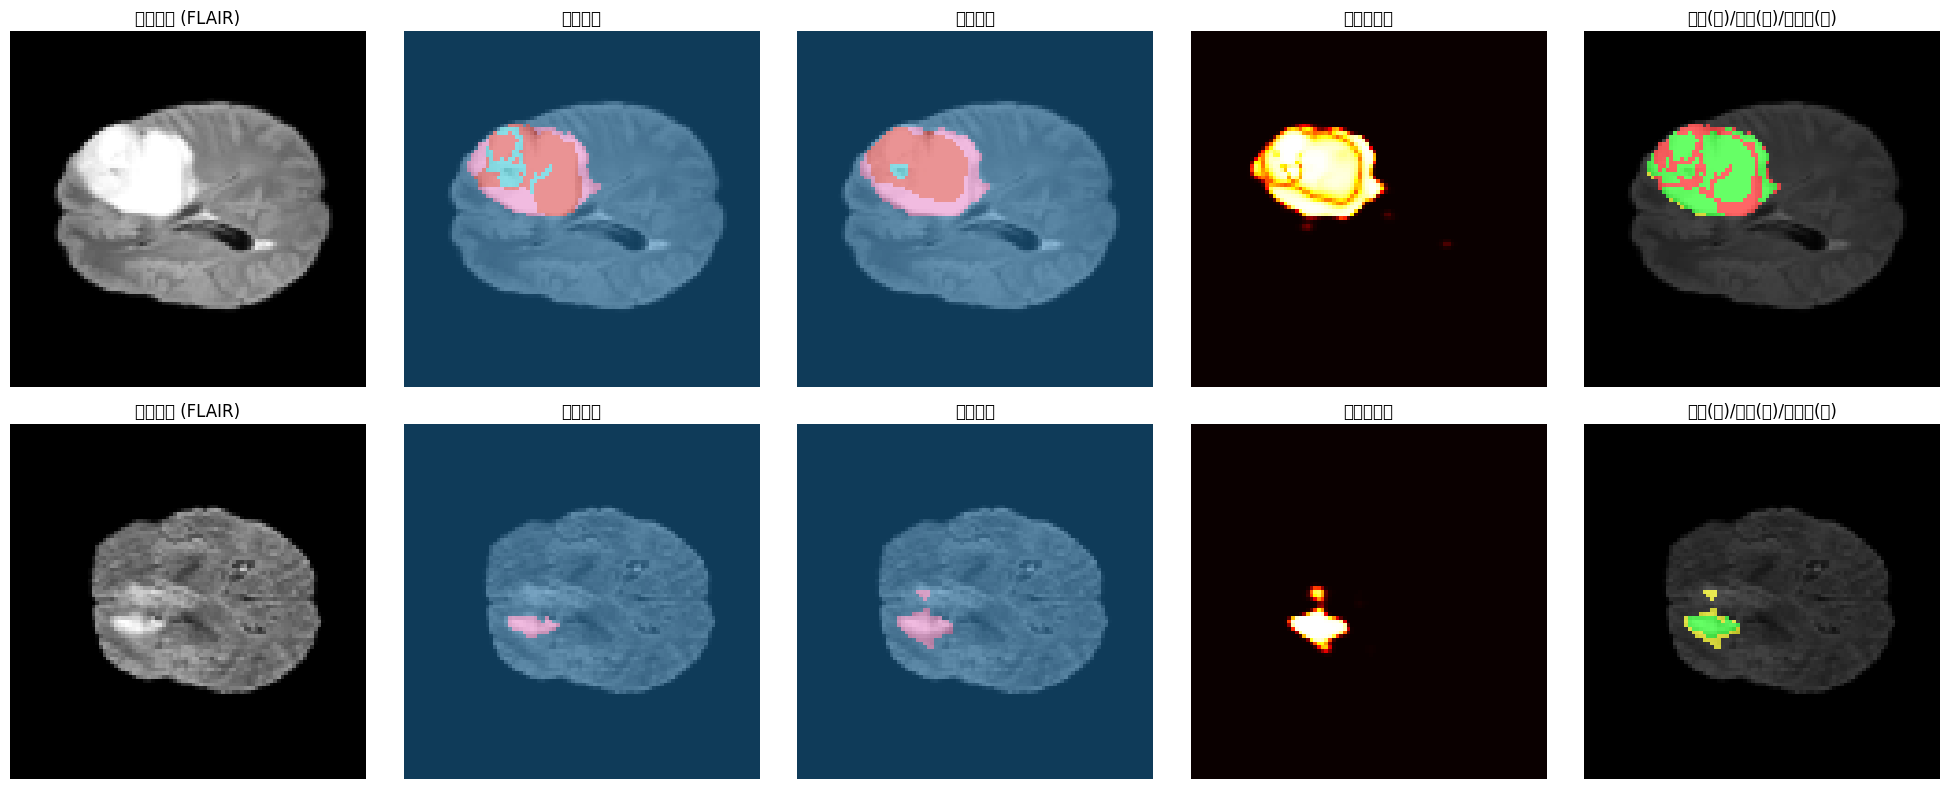

无显著改善，计数: 1/10
训练 - Loss: 0.1794, Dice: 0.7668
验证 - Loss: 0.2882, Dice: 0.6724
时间: 1266.3s

Epoch 22/100
  Batch   0/148, Loss: 0.2093, Dice: 0.7378
  Batch  20/148, Loss: 0.1474, Dice: 0.7808
  Batch  40/148, Loss: 0.1432, Dice: 0.8087
  Batch  60/148, Loss: 0.1353, Dice: 0.8476
  Batch  80/148, Loss: 0.3318, Dice: 0.6866
  Batch 100/148, Loss: 0.2080, Dice: 0.7670
  Batch 120/148, Loss: 0.1808, Dice: 0.7607
  Batch 140/148, Loss: 0.2740, Dice: 0.7192


<Figure size 640x480 with 0 Axes>

无显著改善，计数: 2/10
训练 - Loss: 0.1714, Dice: 0.7750
验证 - Loss: 0.2436, Dice: 0.6861
时间: 1276.4s

Epoch 23/100
  Batch   0/148, Loss: 0.1990, Dice: 0.7689
  Batch  20/148, Loss: 0.1141, Dice: 0.8385
  Batch  40/148, Loss: 0.2034, Dice: 0.7403
  Batch  60/148, Loss: 0.1246, Dice: 0.8342
  Batch  80/148, Loss: 0.1055, Dice: 0.8752
  Batch 100/148, Loss: 0.2027, Dice: 0.7343
  Batch 120/148, Loss: 0.1346, Dice: 0.8157
  Batch 140/148, Loss: 0.1555, Dice: 0.7934


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.7078 (+0.0105)
训练 - Loss: 0.1713, Dice: 0.7734
验证 - Loss: 0.2291, Dice: 0.7078
时间: 1278.3s

Epoch 24/100
  Batch   0/148, Loss: 0.1162, Dice: 0.8403
  Batch  20/148, Loss: 0.1507, Dice: 0.7947
  Batch  40/148, Loss: 0.1506, Dice: 0.7726
  Batch  60/148, Loss: 0.1134, Dice: 0.8468
  Batch  80/148, Loss: 0.1866, Dice: 0.7348
  Batch 100/148, Loss: 0.1570, Dice: 0.7650
  Batch 120/148, Loss: 0.1741, Dice: 0.7850
  Batch 140/148, Loss: 0.2511, Dice: 0.6800


<Figure size 640x480 with 0 Axes>

保存最佳模型，验证Dice: 0.7092 (+0.0015)
训练 - Loss: 0.1669, Dice: 0.7789
验证 - Loss: 0.2299, Dice: 0.7092
时间: 1277.0s

Epoch 25/100
  Batch   0/148, Loss: 0.1146, Dice: 0.8591
  Batch  20/148, Loss: 0.2466, Dice: 0.7295
  Batch  40/148, Loss: 0.2184, Dice: 0.7563
  Batch  60/148, Loss: 0.1419, Dice: 0.7895
  Batch  80/148, Loss: 0.1435, Dice: 0.7972
  Batch 100/148, Loss: 0.1573, Dice: 0.7965
  Batch 120/148, Loss: 0.1849, Dice: 0.7484
  Batch 140/148, Loss: 0.1384, Dice: 0.7913


<Figure size 640x480 with 0 Axes>

无显著改善，计数: 1/10
训练 - Loss: 0.1638, Dice: 0.7828
验证 - Loss: 0.2456, Dice: 0.6933
时间: 1276.9s
检查点已保存到Google Drive: D:/brain_tumor_project/BraTS_Checkpoints\checkpoint_epoch_25.pth

生成分割效果示意图 (Epoch 25)...
 分割可视化失败: [Errno 2] No such file or directory: '/content/drive/MyDrive/BraTS_Checkpoints/segmentation_epoch_25.png'

Epoch 26/100
  Batch   0/148, Loss: 0.1520, Dice: 0.8219
  Batch  20/148, Loss: 0.2107, Dice: 0.7580
  Batch  40/148, Loss: 0.1240, Dice: 0.8171
  Batch  60/148, Loss: 0.1592, Dice: 0.7957
  Batch  80/148, Loss: 0.1485, Dice: 0.8050
  Batch 100/148, Loss: 0.1301, Dice: 0.8202
  Batch 120/148, Loss: 0.1081, Dice: 0.8576
  Batch 140/148, Loss: 0.0831, Dice: 0.8865


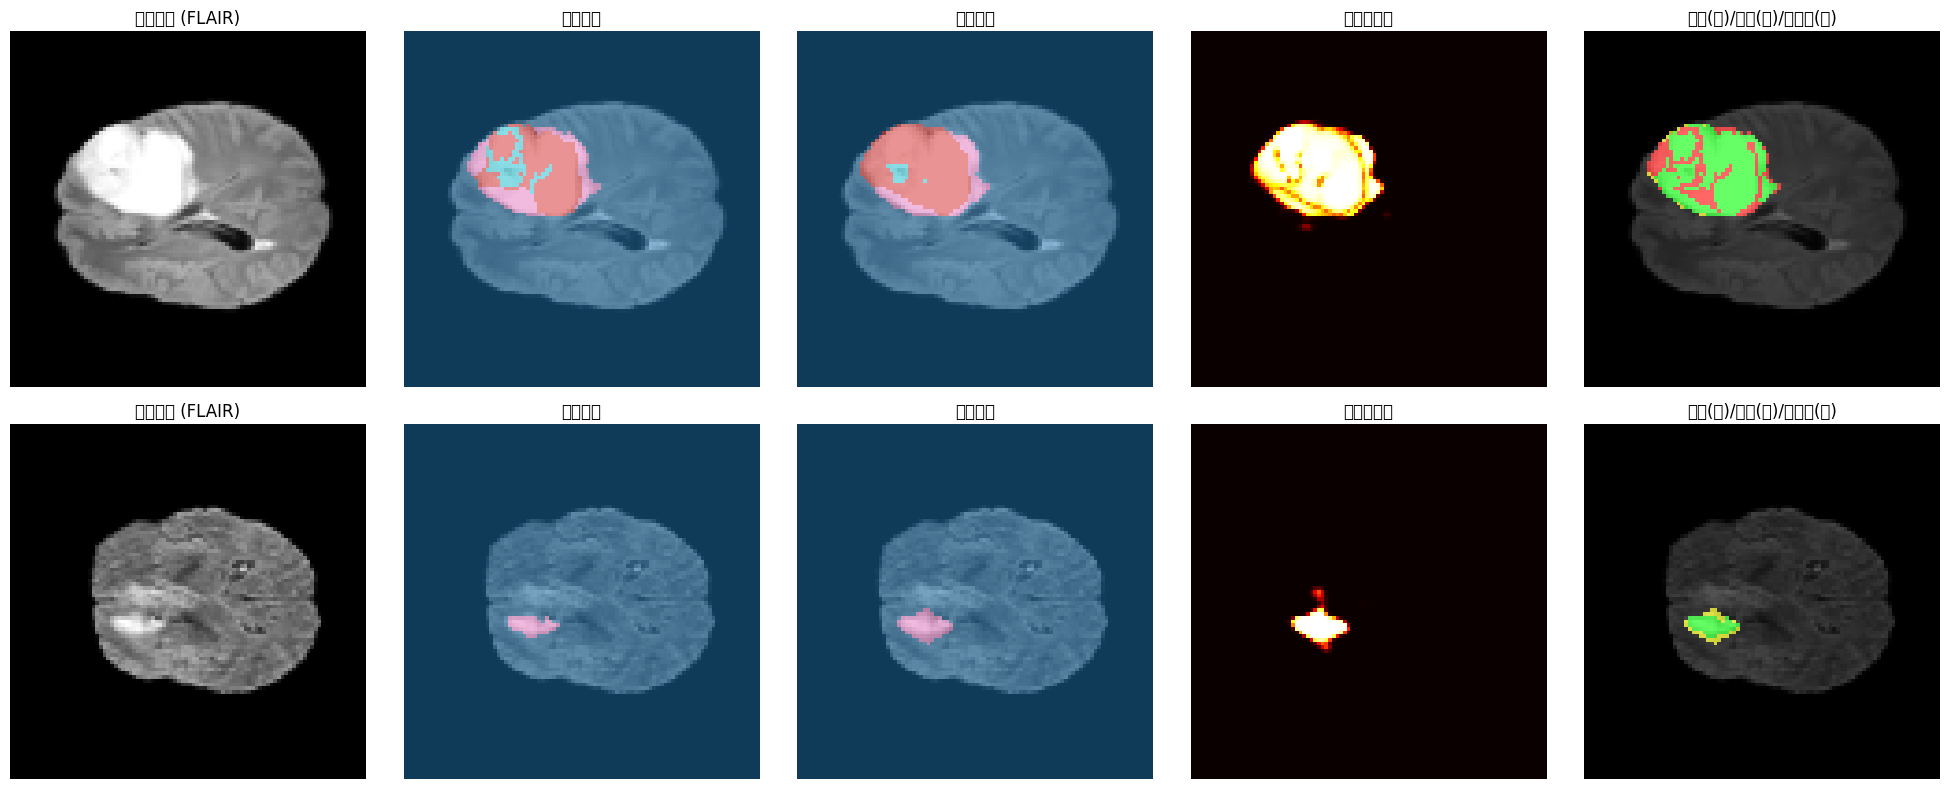

保存最佳模型，验证Dice: 0.7119 (+0.0026)
训练 - Loss: 0.1608, Dice: 0.7887
验证 - Loss: 0.2379, Dice: 0.7119
时间: 1271.7s

Epoch 27/100
  Batch   0/148, Loss: 0.1339, Dice: 0.8052


In [ ]:
print("创建数据加载器...")
train_loader, val_loader = create_brats_data_loaders()

print("\n" + "="*50)
print("开始带实时可视化的FA-UNet训练")
print("="*50)

# 开始训练！
resume_from_checkpoint = None

model, train_losses, val_losses, train_dices, val_dices = main_training_with_visualization(
    resume_from_checkpoint=None
)

In [ ]:
checkpoint_path = "D:/brain_tumor_project/BraTS_Checkpoints/best_model.pth"

print("恢复训练（学习率已重置）...")
model, train_losses, val_losses, train_dices, val_dices = main_training_with_visualization(
    resume_from_checkpoint=checkpoint_path
)

恢复训练（学习率已重置）...
使用设备: cuda
检查点保存路径: D:/brain_tumor_project/BraTS_Checkpoints
BraTS模型配置:
  输入通道: 4 (t1, t1ce, t2, flair)
  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)
  基础通道: 32
  参数量: 22,484,484
从检查点恢复训练: D:/brain_tumor_project/BraTS_Checkpoints/best_model.pth
学习率调整为: 6e-5
恢复从 epoch 26 开始，最佳Dice: 0.7119

开始训练，最多 100 个epochs
早停机制: 连续 10 个epochs改善小于 0.001 时停止

Epoch 1/100
  Batch   0/148, Loss: 0.1964, Dice: 0.7093
  Batch  20/148, Loss: 0.2172, Dice: 0.7616
  Batch  40/148, Loss: 0.1440, Dice: 0.8007
  Batch  60/148, Loss: 0.1476, Dice: 0.8251
  Batch  80/148, Loss: 0.1258, Dice: 0.8466
  Batch 100/148, Loss: 0.1456, Dice: 0.7988
  Batch 120/148, Loss: 0.1838, Dice: 0.7684


In [ ]:

def analyze_final_results(model, dataloader, device):
    """训练结束后的详细分析"""
    print("\n" + "="*50)
    print("最终结果分析")
    print("="*50)

    # 可视化多个样本
    fig = visualize_segmentation(model, dataloader, device, num_samples=4)
    fig.savefig('/content/drive/MyDrive/BraTS_Checkpoints/final_segmentation_results.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # 计算详细指标
    model.eval()
    total_dice = 0.0
    total_samples = 0

    dice_per_class = {1: 0.0, 2: 0.0, 3: 0.0}  # 坏死, 水肿, 增强肿瘤

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # 计算每个类别的Dice
            for class_id in [1, 2, 3]:
                dice = dice_coefficient_per_class(output, target, class_id)
                dice_per_class[class_id] += dice.item()

            total_dice += dice_coefficient(output, target).mean().item()
            total_samples += 1

    # 打印详细结果
    print("\n 各类别性能分析:")
    print(f"总体Dice: {total_dice/total_samples:.4f}")
    for class_id, dice_sum in dice_per_class.items():
        class_names = {1: '坏死', 2: '水肿', 3: '增强肿瘤'}
        print(f"{class_names[class_id]} Dice: {dice_sum/total_samples:.4f}")

def dice_coefficient_per_class(pred, target, class_id, smooth=1e-6):
    """计算单个类别的Dice系数"""
    pred_class = (torch.softmax(pred, dim=1)[:, class_id] > 0.5).float()
    target_class = (target == class_id).float()

    intersection = (pred_class * target_class).sum()
    union = pred_class.sum() + target_class.sum()

    return (2. * intersection + smooth) / (union + smooth)

analyze_final_results(model, val_loader, device)

In [ ]:
# 简化调试版本 - 不依赖外部导入
def simple_debug():
    """简化调试 - 只检查数据和标签"""
    print("=== 数据标签调试 ===")

    # 1. 数据检查
    data, target = next(iter(train_loader))
    print(f"1. 输入数据: {data.shape}, 范围: [{data.min():.3f}, {data.max():.3f}]")

    # 2. 标签检查
    unique, counts = torch.unique(target, return_counts=True)
    label_dist = dict(zip(unique.tolist(), counts.tolist()))
    print(f"2. 标签分布: {label_dist}")

    # 3. 计算类别权重建议
    total_voxels = sum(label_dist.values())
    print(f"3. 总体素数: {total_voxels}")

    # 建议的类别权重（逆频率）
    suggested_weights = {}
    for class_id, count in label_dist.items():
        weight = total_voxels / (len(label_dist) * count)  # 逆频率加权
        suggested_weights[class_id] = weight
        print(f"   类别 {class_id}: {count}体素 → 建议权重: {weight:.2f}")

    return suggested_weights

# 运行简化调试
suggested_weights = simple_debug()

=== 数据标签调试 ===
1. 输入数据: torch.Size([2, 4, 96, 96, 96]), 范围: [-0.452, 5.355]
2. 标签分布: {0: 1737158, 1: 964, 2: 24557, 3: 6793}
3. 总体素数: 1769472
   类别 0: 1737158体素 → 建议权重: 0.25
   类别 1: 964体素 → 建议权重: 458.89
   类别 2: 24557体素 → 建议权重: 18.01
   类别 3: 6793体素 → 建议权重: 65.12


In [ ]:
import time
print("\n=== 数据加载器性能测试 ===")

# 测试纯数据加载（不训练）
model = create_brats_model().to(device)
model.eval()

with torch.no_grad():
    start_time = time.time()
    batch_count = 0

    for i, (data, target) in enumerate(train_loader):
        if i >= 5:  # 只测试5个batch
            break

        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)

        batch_count += 1
        if i % 1 == 0:
            current_time = time.time() - start_time
            print(f"Batch {i}: {current_time/(i+1):.1f}s/batch")

    total_time = time.time() - start_time
    print(f"\n平均速度: {total_time/batch_count:.1f}秒/batch")
    print(f"预计每个epoch: {(total_time/batch_count)*len(train_loader)/60:.1f}分钟")


=== 数据加载器性能测试 ===
BraTS模型配置:
  输入通道: 4 (t1, t1ce, t2, flair)
  输出类别: 4 (背景, 坏死, 水肿, 增强肿瘤)
  基础通道: 32
  参数量: 22,484,484
Batch 0: 17.6s/batch
Batch 1: 8.8s/batch
Batch 2: 8.0s/batch
Batch 3: 6.7s/batch
Batch 4: 6.1s/batch

平均速度: 10.6秒/batch
预计每个epoch: 26.2分钟


In [ ]:
# 从保存的检查点读取
checkpoint_path = "/content/drive/MyDrive/BraTS_Checkpoints/best_model.pth"
checkpoint = torch.load(checkpoint_path)

print("检查点中的优化器状态:")
optimizer_state = checkpoint['optimizer_state_dict']
print(f"学习率: {optimizer_state['param_groups'][0]['lr']:.2e}")

检查点中的优化器状态:
学习率: 1.00e-05
